# Mental Health Prediction - Depression Classification

In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({'font.size': 10})

PRIMARY_COLOR = '#2ecc71'
SECONDARY_COLOR = 'steelblue'
TITLE_FONT = {'fontsize': 12, 'fontweight': 'bold', 'color': '#2c3e50'}

## Tổng quan dữ liệu

Kiểm tra kích thước dữ liệu, kiểu dữ liệu của các đặc trưng, thống kê mô tả

In [2]:
train_path = '../data/train.csv'
test_path = '../data/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train shape: ', train_df.shape)
print('Test shape: ', test_df.shape)

train_df.head()

Train shape:  (140700, 20)
Test shape:  (93800, 19)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [3]:
print('BẢNG THỐNG KÊ CHI TIẾT CÁC ĐẶC TRƯNG:\n')
print('='*80)

summary_df = pd.DataFrame({
    'Kiểu dữ liệu': train_df.dtypes,
    'Số lượng (Non-Null)': train_df.notna().sum(),
    'Số lượng Unique': train_df.nunique()
})

display(summary_df)

BẢNG THỐNG KÊ CHI TIẾT CÁC ĐẶC TRƯNG:



,Kiểu dữ liệu,Số lượng (Non-Null),Số lượng Unique
id,int64,140700,140700
Name,object,140700,422
Gender,object,140700,2
Age,float64,140700,43
City,object,140700,98
Working Professional or Student,object,140700,2
Profession,object,104070,64
Academic Pressure,float64,27897,5
Work Pressure,float64,112782,5
CGPA,float64,27898,331


In [4]:
train_df.drop(columns=['id']).describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


Các đặc trưng số có thang đo giá trị khác nhau, tuy nhiên nếu ta chỉ sử dụng các mô hình tree-based (Random Forest, XGBoost, Light GBM) thì không yêu cầu feature scaling.

Nếu sử dụng thì có các loại scaler sau:

- Min-max scaling
- Standard scaling
- Robust scaling

## Phân tích dữ liệu thiếu

In [5]:
print("="*50)
print("THỐNG KÊ CÁC GIÁ TRỊ BỊ THIẾU")
print("="*50)

missing_df = pd.DataFrame({
    'Missing Train': train_df.isnull().sum(),
    '% Missing Train': (train_df.isnull().sum() / len(train_df)) * 100,
    'Unique Values': train_df.nunique()
}).sort_values(by='% Missing Train', ascending=False)

print("Các cột có Missing Value trong tập Train:")
display(missing_df[missing_df['% Missing Train'] > 0])

THỐNG KÊ CÁC GIÁ TRỊ BỊ THIẾU
Các cột có Missing Value trong tập Train:


,Missing Train,% Missing Train,Unique Values
Study Satisfaction,112803,80.172708,5
Academic Pressure,112803,80.172708,5
CGPA,112802,80.171997,331
Profession,36630,26.034115,64
Work Pressure,27918,19.842217,5
Job Satisfaction,27910,19.836532,5
Financial Stress,4,0.002843,5
Dietary Habits,4,0.002843,23
Degree,2,0.001421,115


- Mất thông tin nhiều ở các thuộc tính Study Satisfaction (**80.2**%), Academic Pressure (**80.2**%), CGPA (**80.2**%), Profession (**26**%), Work Pressure (**19.8**%), Job Satisfaction (**19.8**%).
- Mất thông tin không đáng kể ở các thuộc tính Dietary Habits, Financial Stress, Degree (≈**0**%)

Kiểm tra xem dữ liệu bị thiếu là ngẫu nhiên hoàn toàn hay ngẫu nhiên có quy luật bằng cách thống kê theo đối tượng là `Student`/`Working Professional` theo đặc trưng `Working Professional or Student`:

- Nhóm các đặc trưng `Academic Pressure`, `CGPA`, `Study Satisfaction` thuộc về đối tượng `Student`.
- Nhóm các đặc trưng `Work Pressure`, `Job Satisfaction`, `Profession` vào đối tượng `Working Professional`.

Như đã thấy ở phần thống kê giá trị thiếu, các đặc trưng trên có thể thiếu theo quy luật: nhóm `Student` thì không có thông tin các đặc trưng của `Working Professional` và ngược lại --> Kiểm tra bằng thống kê trên dữ liệu.

In [6]:
print("="*50)
print("KIỂM TRA LOGIC MISSING VALUES THEO ĐỐI TƯỢNG")
print("="*50)

students = train_df[train_df['Working Professional or Student'] == 'Student']
professionals = train_df[train_df['Working Professional or Student'] == 'Working Professional']

academic_cols = ['Academic Pressure', 'CGPA', 'Study Satisfaction']
work_cols = ['Work Pressure', 'Job Satisfaction', 'Profession']

logic_check = pd.DataFrame({
    'Metric': [
        'Student thiếu thông tin Work (%)', 
        'Working Professional thiếu thông tin Academic (%)'
    ],
    'Value': [
        (students[work_cols].isnull().all(axis=1).sum() / len(students)) * 100,
        (professionals[academic_cols].isnull().all(axis=1).sum() / len(professionals)) * 100
    ]
})

print(f"Tổng số người thuộc nhóm Student: {len(students)}")
print(f"Tổng số người thuộc nhóm Working Professional: {len(professionals)}\n")

print("Tỷ lệ thiếu hụt theo logic nghiệp vụ:")
display(logic_check)

print("-"*20, "BẤT THƯỜNG", "-"*20)
outliers_student = students[students[academic_cols].isnull().any(axis=1)]
outliers_prof = professionals[professionals[work_cols].isnull().any(axis=1)]

print(f"Số Student thiếu thông tin Academic: {len(outliers_student)}")
print(f"Số Working Professional thiếu thông tin Work: {len(outliers_prof)}")

KIỂM TRA LOGIC MISSING VALUES THEO ĐỐI TƯỢNG
Tổng số người thuộc nhóm Student: 27901
Tổng số người thuộc nhóm Working Professional: 112799

Tỷ lệ thiếu hụt theo logic nghiệp vụ:


,Metric,Value
0,Student thiếu thông tin Work (%),99.849468
1,Working Professional thiếu thông tin Academic (%),99.994681


-------------------- BẤT THƯỜNG --------------------
Số Student thiếu thông tin Academic: 14
Số Working Professional thiếu thông tin Work: 8765


**Nhận xét về Missing Values**

- Thực trạng: Dữ liệu có tỷ lệ giá trị thiếu khá cao ở các cột như `Profession`, `CGPA`, `Academic Pressure`, `Work Pressure`, `Study Satisfaction`, `Job Satisfaction`

- Lý do và Insight: Các giá trị thiếu này không hoàn toàn ngẫu nhiên mà tuân theo một logic rõ ràng giữa hai nhóm đối tượng:

    - `Student` thường thiếu dữ liệu liên quan đến công việc (Profession, Work Pressure,...).
    - `Working Professional` thường thiếu thông tin học thuật (CGPA, Academic Pressure,...).

Ngoài ra, số lượng bất thường, tức số `Student` thiếu thông tin học thuật hoặc `Working Professional` thiếu thông tin nghề nghiệp là không đáng kể so với tổng số mẫu tương ứng, cho thấy tính nhất quán cao trong cấu trúc dữ liệu.

## Phân tích đơn biến

**Phân phối dữ liệu theo biến đặc trưng**

BIỂU ĐỒ PHÂN PHỐI DỮ LIỆU THEO BIẾN MỤC TIÊU


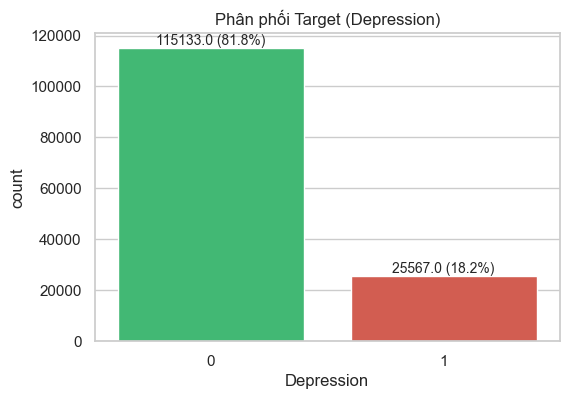

In [7]:
print("="*50)
print("BIỂU ĐỒ PHÂN PHỐI DỮ LIỆU THEO BIẾN MỤC TIÊU")
print("="*50)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train_df, x='Depression', hue='Depression', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Phân phối Target (Depression)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({100 * p.get_height() / len(train_df):.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

Dựa trên biểu đồ tần suất của cột Depression, ta có các quan sát sau:
- Tỉ lệ phân bổ: Tập dữ liệu có sự chênh lệch lớn giữa 2 lớp (81,8% cho lớp 0 và 18.2% cho lớp 1) => Mất cân bằng dữ liệu (dữ liệu bị thiên về biến 0).
- Cần đánh giá mô hình bằng **F1-score**, **Recall**, **Precision**, **AUC-ROC**, **PR-Curve** chứ không chỉ phụ thuộc vào **Accuracy**.

Các đề xuất xử lý Imbalance:
- Stratified K-Fold: Khi chia dữ liệu để train/val/test thì nó vẫn đảm bảo được tỉ lệ class là như nhau ở mỗi fold.
- Cost-Sensitive Learning: Đánh trọng số phạt cao hơn cho class xuất hiện ít.
- SMOTE ???

Tham khảo: [Link](https://phamdinhkhanh.github.io/2020/02/17/ImbalancedData.html)

In [8]:
# Tỉ lệ trầm cảm theo từng nhóm tuổi

**Thống kê phân phối của các đặc trưng**

In [9]:
features = [c for c in train_df.columns if c not in ['Depression', 'id', 'Name']]
num_cols = train_df[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_df[features].select_dtypes(include=['object', 'string', 'category']).columns.tolist()

PHÂN TÍCH ĐƠN BIẾN: ĐẶC TRƯNG SỐ


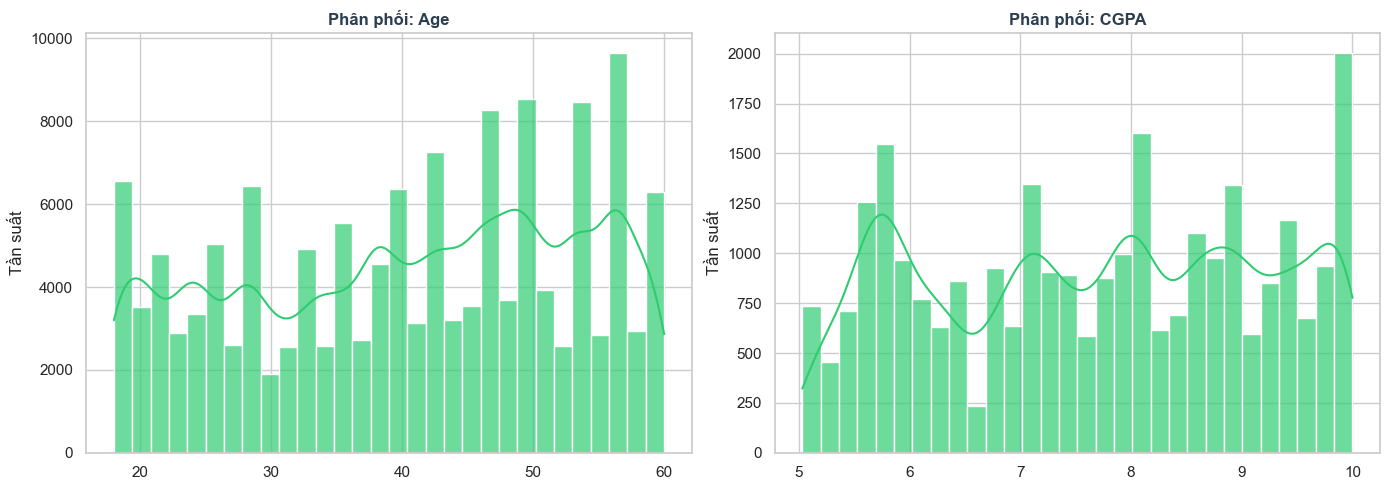

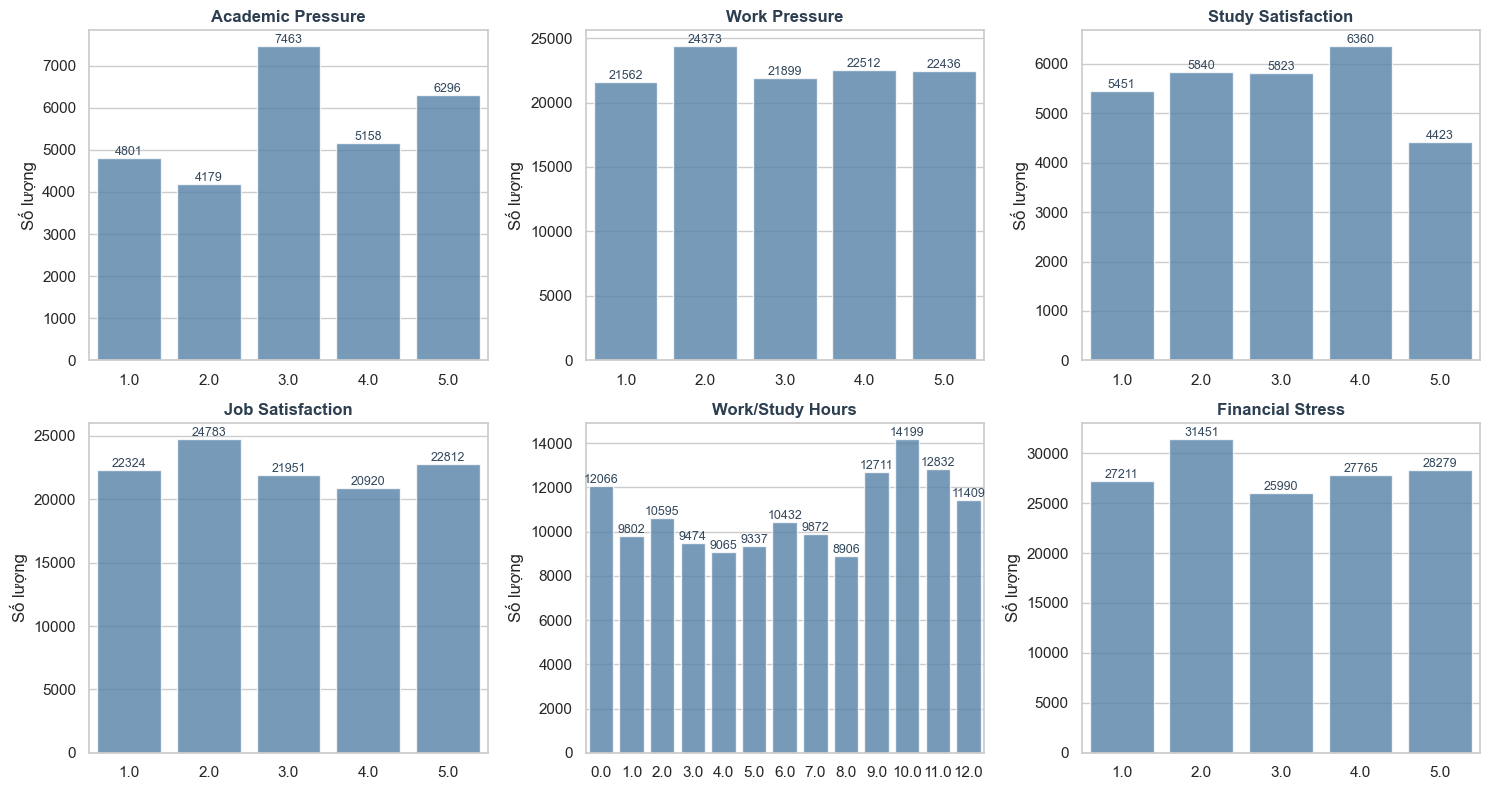

In [10]:
print("="*50)
print("PHÂN TÍCH ĐƠN BIẾN: ĐẶC TRƯNG SỐ")
print("="*50)

continuous_cols = ['Age', 'CGPA']
numeric_features = [col for col in num_cols if col not in continuous_cols + ['id', 'Depression']]

if len(continuous_cols) > 0:
    fig, axes = plt.subplots(1, len(continuous_cols), figsize=(14, 5))
    if len(continuous_cols) == 1: axes = [axes]
    
    for i, col in enumerate(continuous_cols):
        sns.histplot(data=train_df, x=col, kde=True, ax=axes[i], bins=30, color=PRIMARY_COLOR, edgecolor='white', alpha=0.7)
        axes[i].set_title(f'Phân phối: {col}', **TITLE_FONT)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Tần suất')
        
    plt.tight_layout()
    plt.show()

if len(numeric_features) > 0:
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(numeric_features):
        sns.countplot(data=train_df, x=col, ax=axes[i], color=SECONDARY_COLOR, alpha=0.8)
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9, color='#34495e')
            
        axes[i].set_title(col, **TITLE_FONT)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Số lượng')

    for j in range(len(numeric_features), len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

ĐẶC TRƯNG PHÂN LOẠI (CHO CÁC ĐẶC TRƯNG CÓ KHÔNG QUÁ 10 GIÁ TRỊ)


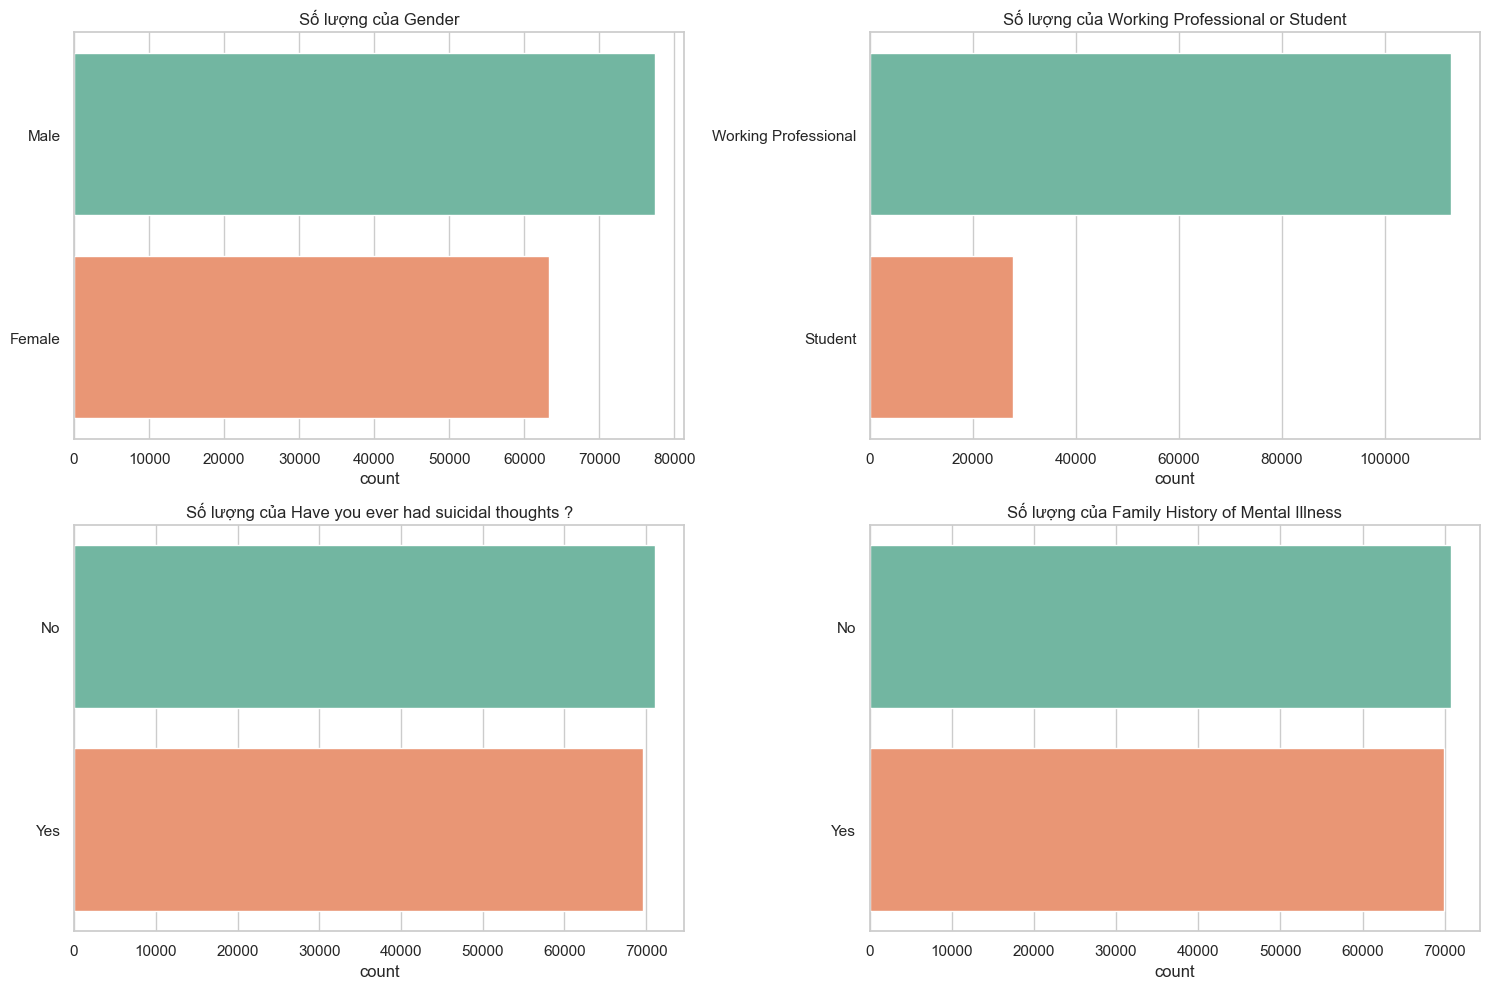

In [11]:
print("="*50)
print("ĐẶC TRƯNG PHÂN LOẠI (CHO CÁC ĐẶC TRƯNG CÓ KHÔNG QUÁ 10 GIÁ TRỊ)")
print("="*50)
cat_cols_to_plot = [c for c in cat_cols if train_df[c].nunique() <= 10]
if len(cat_cols_to_plot) > 0:
    n_cols = 2
    n_rows = int(np.ceil(len(cat_cols_to_plot) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(cat_cols_to_plot):
        sns.countplot(data=train_df, y=col, ax=axes[i], order=train_df[col].value_counts().index, palette='Set2')
        axes[i].set_title(f'Số lượng của {col}')
        axes[i].set_ylabel('')
    
    for j in range(len(cat_cols_to_plot), len(axes)): axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

ĐẶC TRƯNG PHÂN LOẠI (CHO CÁC ĐẶC TRƯNG CÓ TRÊN 10 GIÁ TRỊ)


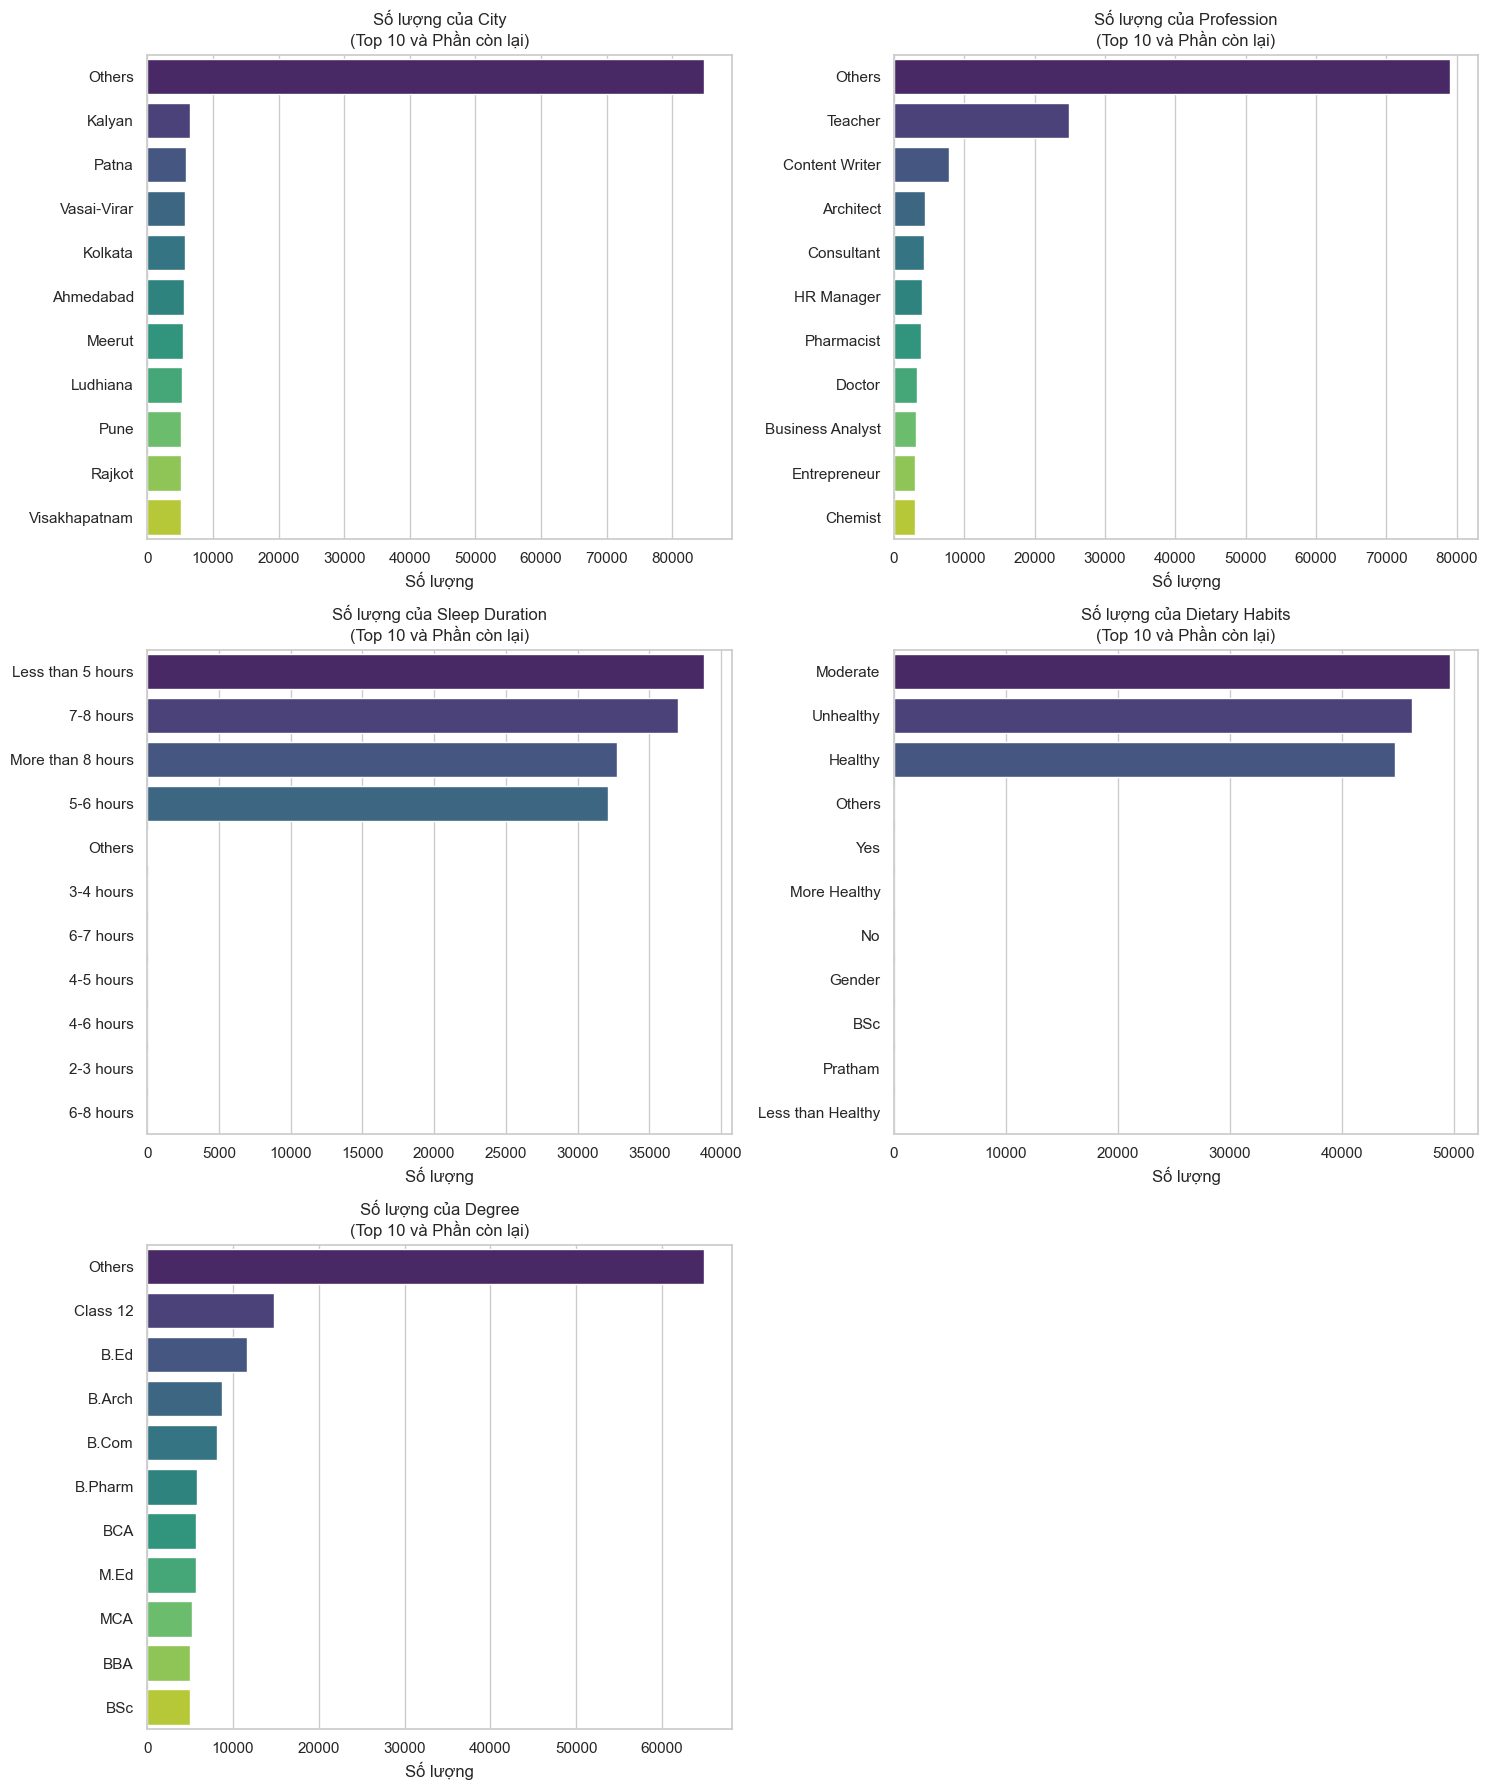

In [12]:
print("="*50)
print("ĐẶC TRƯNG PHÂN LOẠI (CHO CÁC ĐẶC TRƯNG CÓ TRÊN 10 GIÁ TRỊ)")
print("="*50)
high_card_cols = [c for c in cat_cols if train_df[c].nunique() > 10]

if len(high_card_cols) > 0:
    n_cols = 2
    n_rows = int(np.ceil(len(high_card_cols) / n_cols)) 
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
    if n_rows == 1: 
        axes = np.array(axes)
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(high_card_cols):
        top_10_values = train_df[col].value_counts().nlargest(10).index
        
        plot_data = train_df[col].apply(lambda x: x if x in top_10_values else 'Others')
        
        sns.countplot(y=plot_data, ax=axes[i], order=plot_data.value_counts().index, palette='viridis')

        axes[i].set_title(f'Số lượng của {col}\n(Top 10 và Phần còn lại)', fontsize=12)
        axes[i].set_ylabel('')
        axes[i].set_xlabel('Số lượng')

    for j in range(len(high_card_cols), len(axes)): 
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

## Phân tích đa biến

**Thống kê tỉ lệ các giá trị của từng đặc trưng so với Target**

THỐNG KÊ CỦA CÁC ĐẶC TRƯNG SỐ SO VỚI TRẦM CẢM


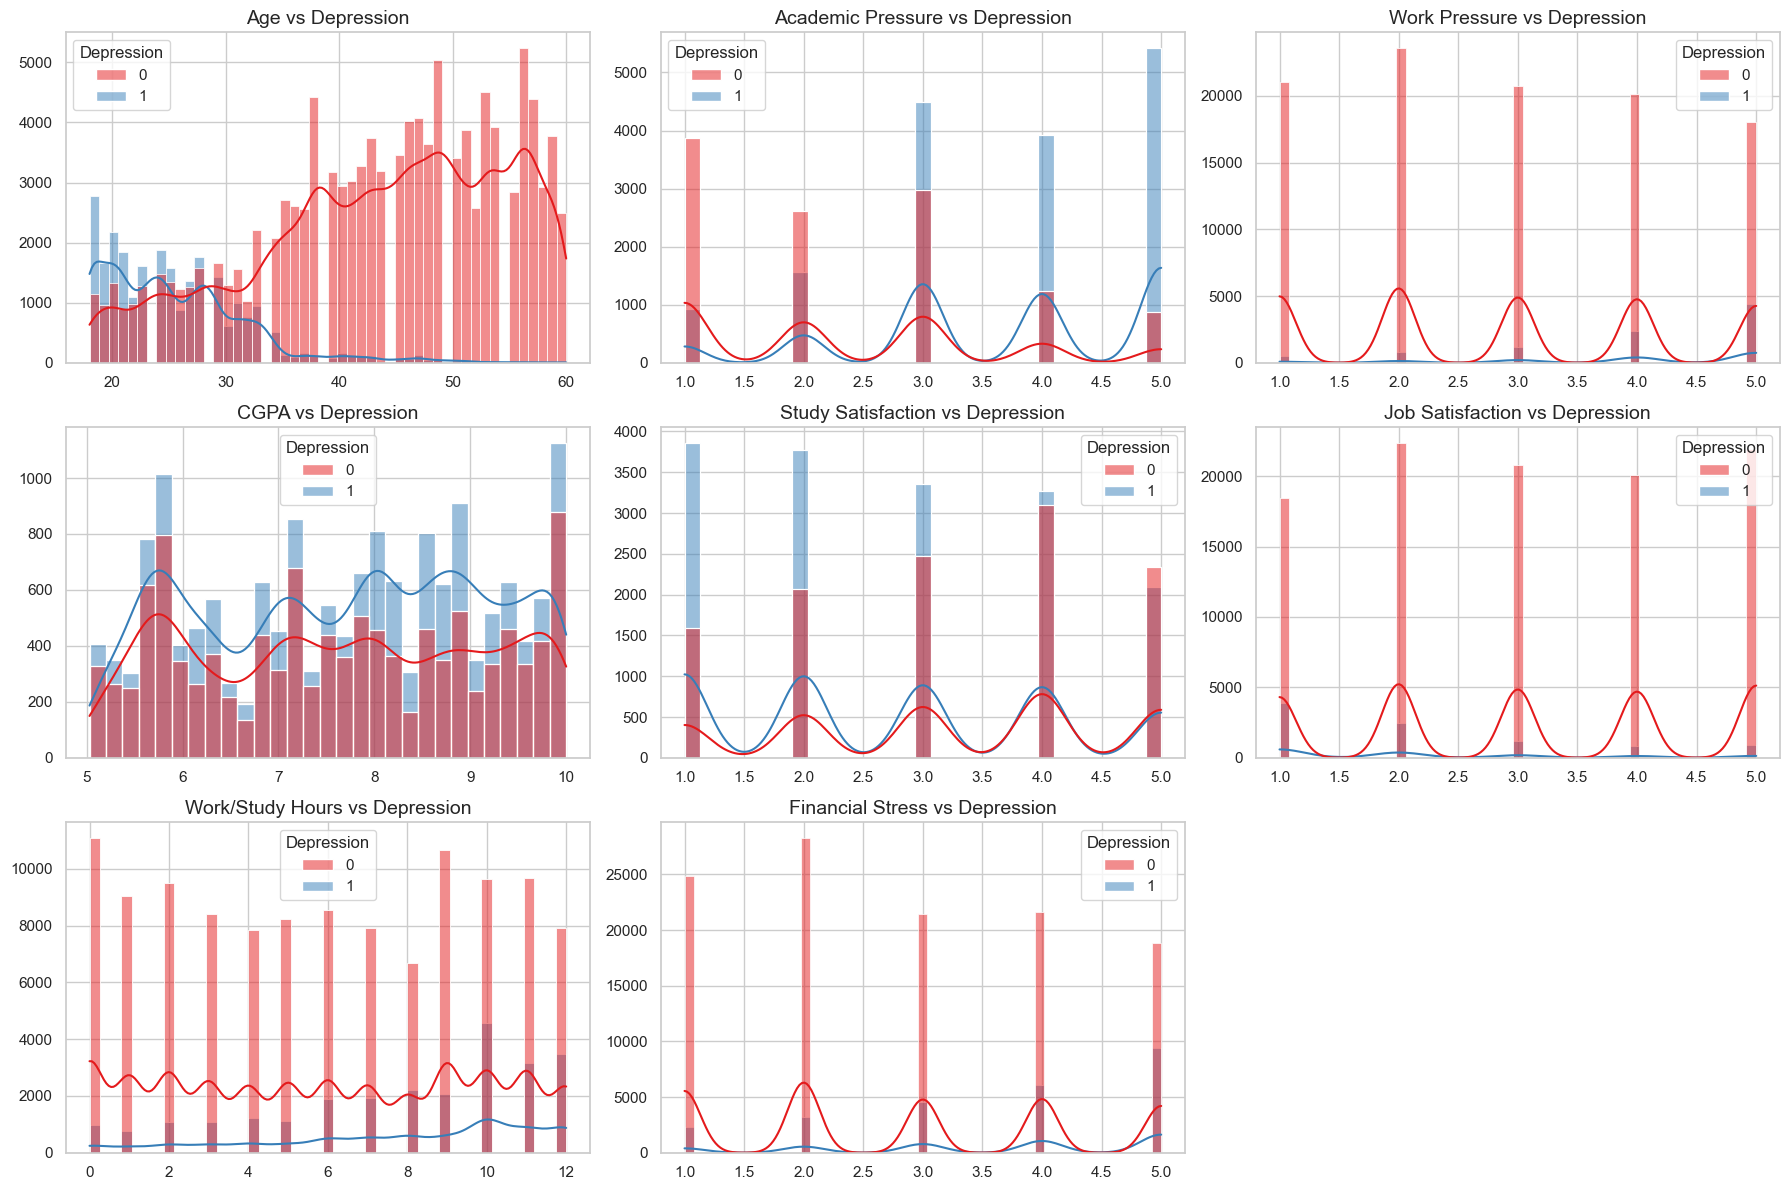

In [13]:
print("="*50)
print("THỐNG KÊ CỦA CÁC ĐẶC TRƯNG SỐ SO VỚI TRẦM CẢM")
print("="*50)

n_rows = (len(num_cols) + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 4))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train_df, x=col, hue='Depression', kde=True, ax=axes[i], palette='Set1', alpha=0.5, multiple="layer")
    
    axes[i].set_title(f'{col} vs Depression', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Nhận xét:

Từ các biểu đồ phân phối của các thuộc tính số với trầm cảm:

- `Age`: Tỉ lệ Depression phần lớn diễn ra ở độ tuổi từ 20 đến 40, trong đó độ tuổi 20-25 có tỉ lệ mắc cao; từ 40 đến 60 hầu như không mắc.
- `Academic Pressure`, `Work Pressure`, `Financial Stress`: Áp lực càng lớn càng dễ mắc trầm cảm (tỉ lệ mắc có xu hướng tăng thuận với áp lực).
- `Work/Study Hours`: Thời gian học/làm việc càng nhiều thì tỉ lệ mắc càng cao.
- `Study Satisfaction` / `Job Satisfaction`: Càng thoả mãn với công việc thì khả năng mắc càng thấp.
- `CGPA`: trong tất cả giá trị trải dài từ 5 tới 10, tỉ lệ mắc và không mắc khá tương đồng nhau, số ca mắc vẫn nhiều hơn, không thể rõ rệt mối quan hệ gì với Depression.

THỐNG KÊ CỦA CÁC ĐẶC TRƯNG PHÂN LOẠI SO VỚI TRẦM CẢM (CHỈ LẤY TOP 10)


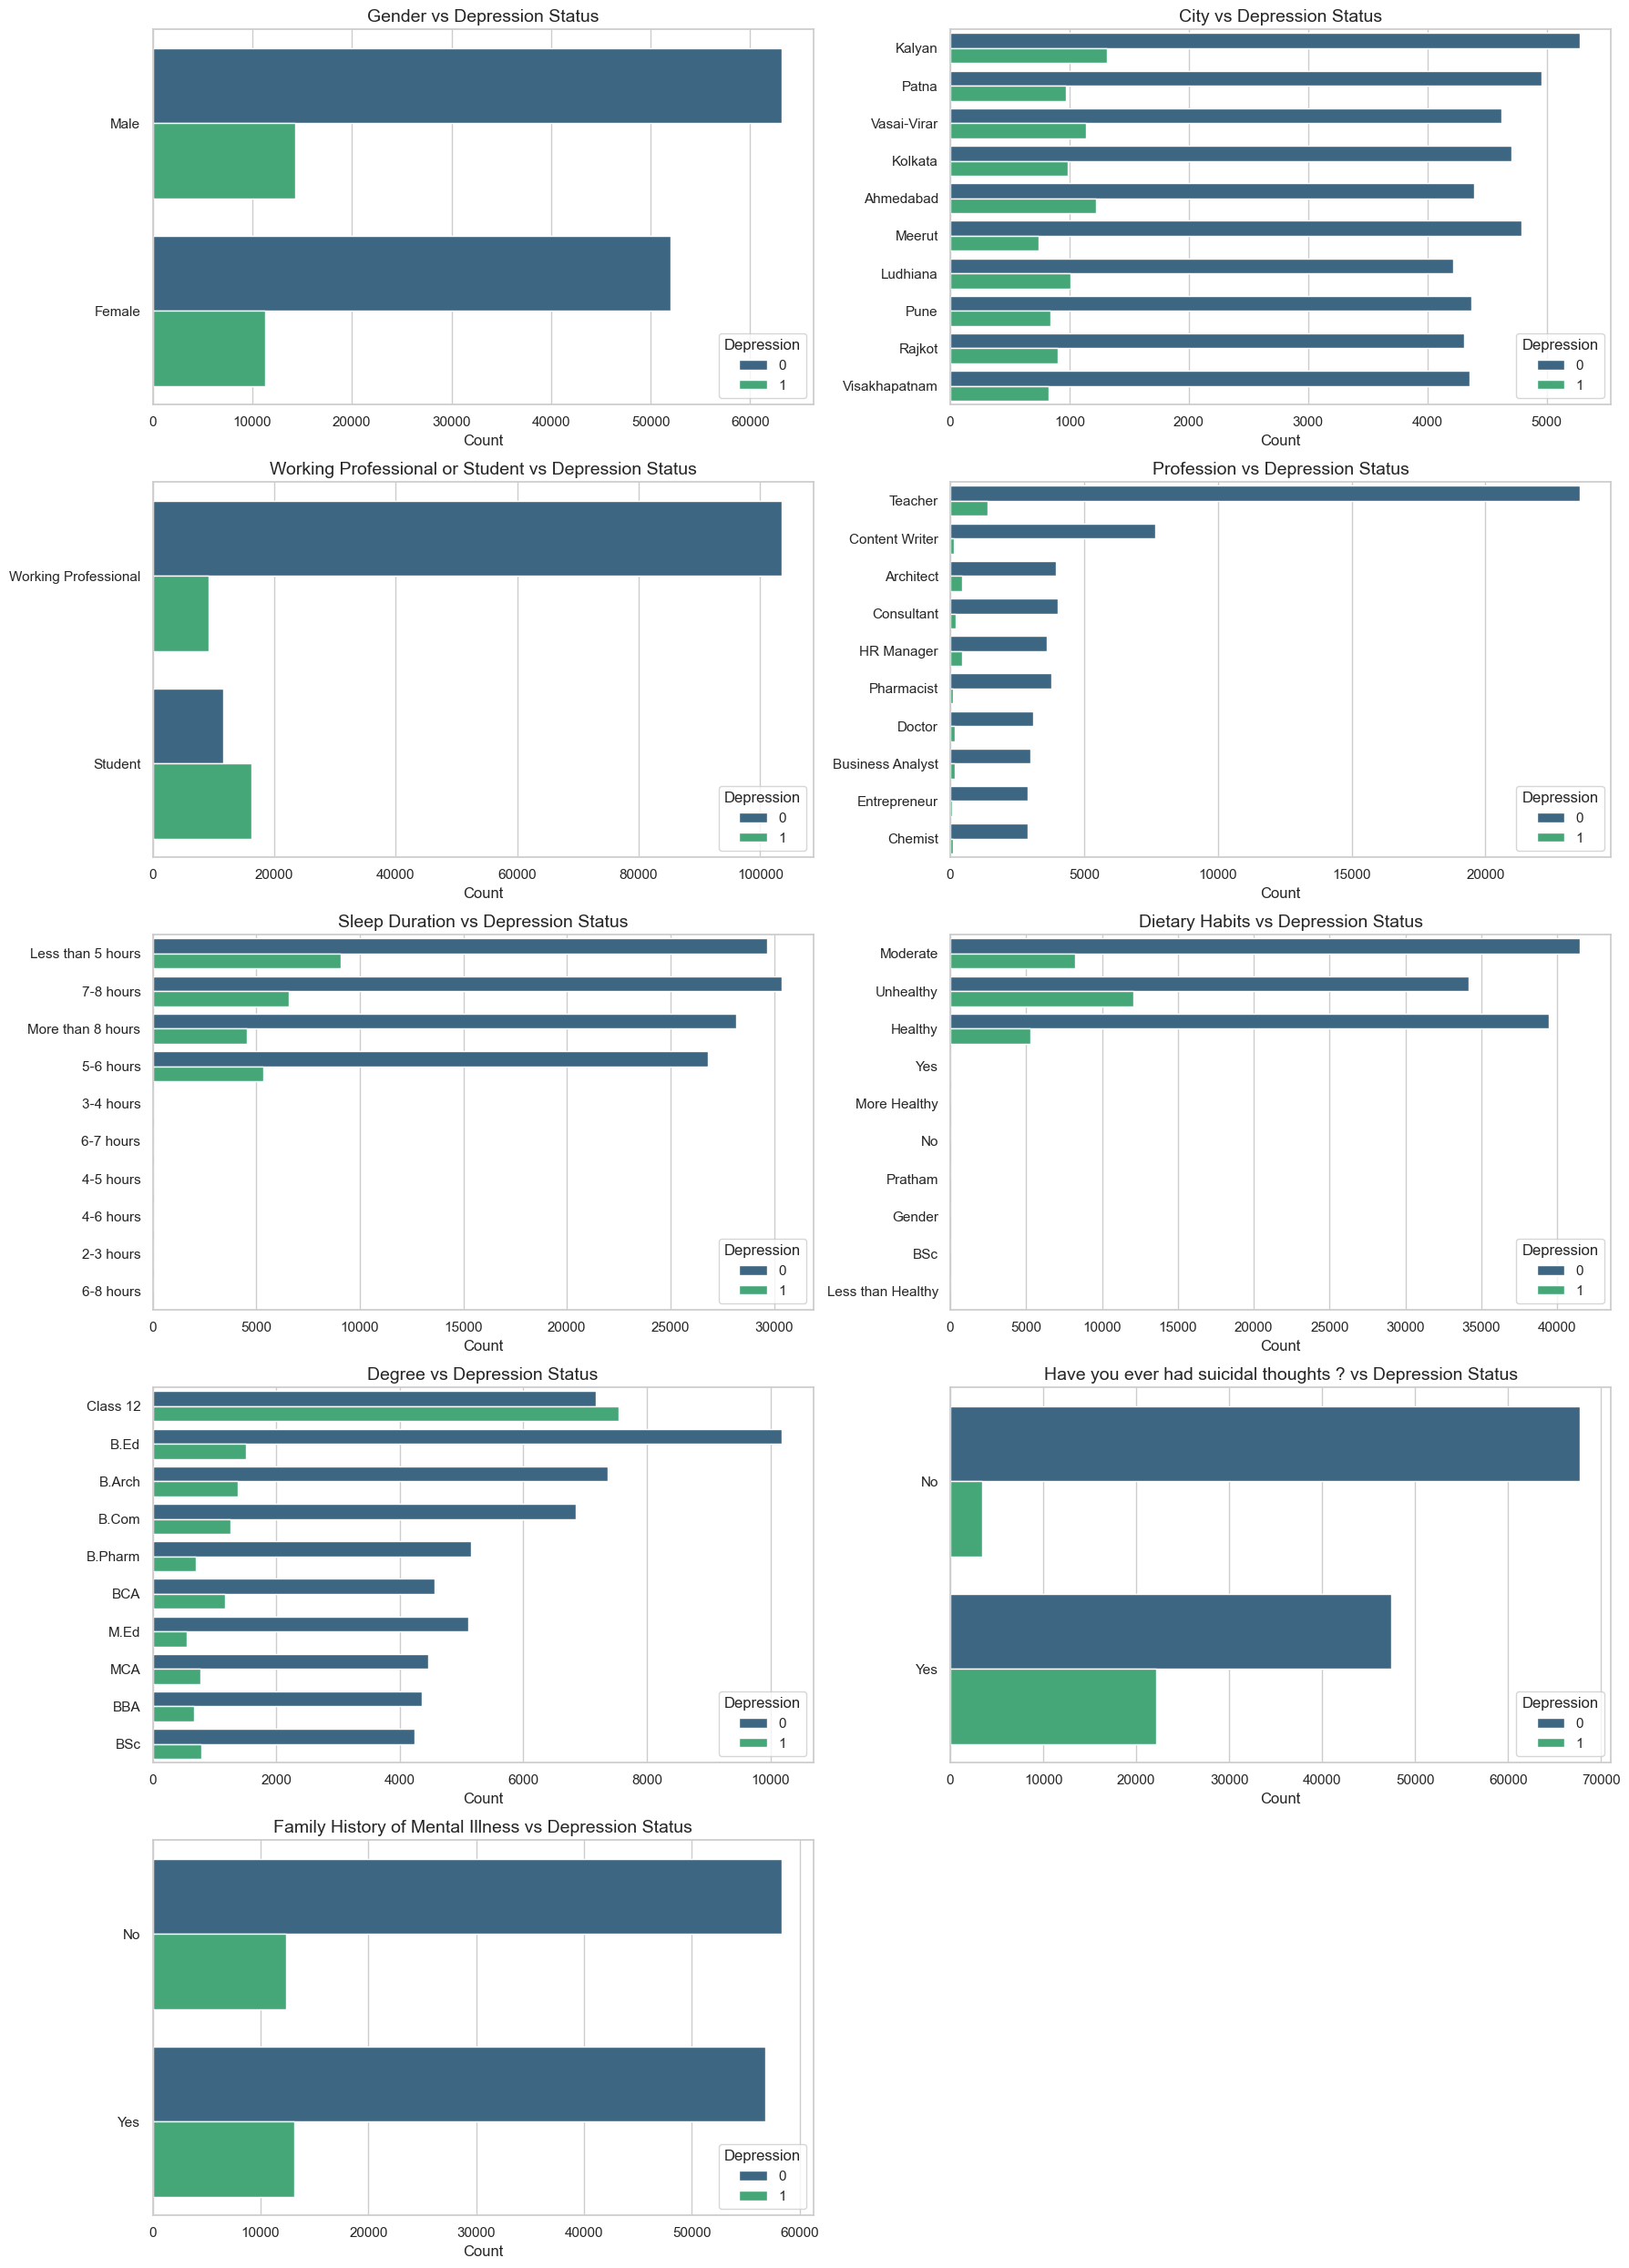

In [14]:
print("="*50)
print("THỐNG KÊ CỦA CÁC ĐẶC TRƯNG PHÂN LOẠI SO VỚI TRẦM CẢM (CHỈ LẤY TOP 10)")
print("="*50)
n_rows_cat = (len(cat_cols) + 1) // 2
fig, axes = plt.subplots(n_rows_cat, 2, figsize=(18, n_rows_cat * 5))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(cat_cols):
    order = train_df[col].value_counts().iloc[:10].index

    sns.countplot(data=train_df, y=col, ax=axes[i], order=order, hue='Depression', palette='viridis')
    
    axes[i].set_title(f'{col} vs Depression Status', fontsize=14)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')
    axes[i].legend(title='Depression', loc='lower right')

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

TỈ LỆ TRẦM CẢM THEO TỪNG NHÓM CATEGORY ĐỐI VỚI TARGET
Biểu đồ cho các nhóm có ít hơn 15 giá trị phân biệt


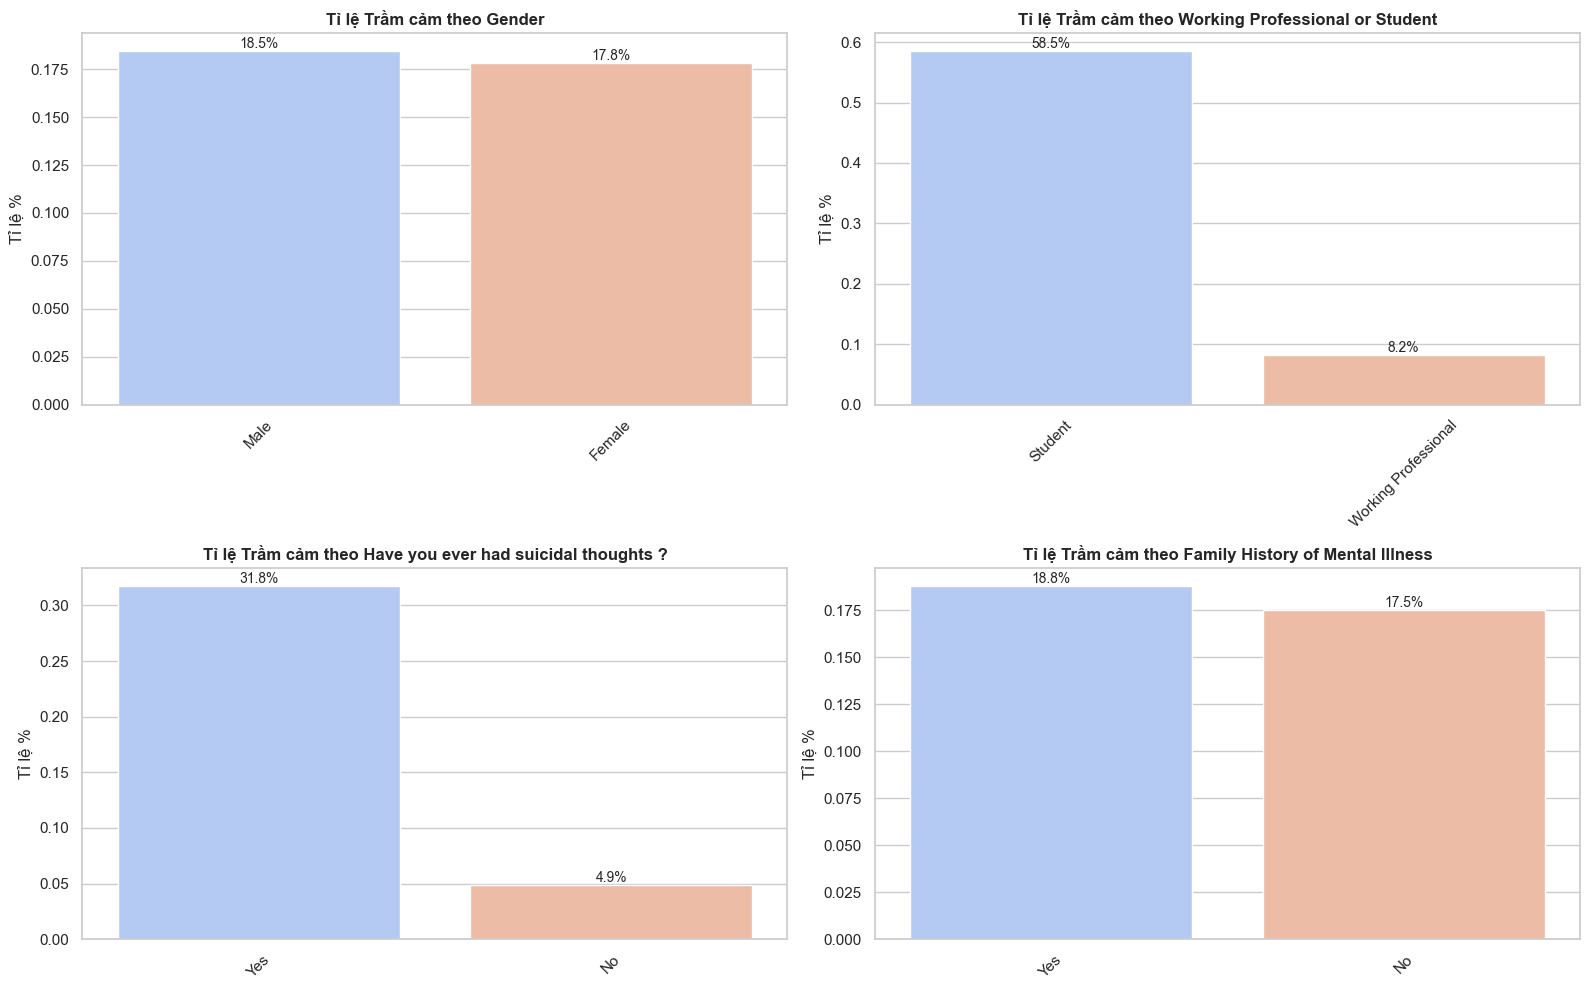

Biểu đồ cho các nhóm có nhiều hơn 15 giá trị phân biệt


TOP 5 NHÓM CÓ TỈ LỆ TRẦM CẢM CAO NHẤT (Chỉ xét nhóm > 50 người):

--- Top 5 City rủi ro nhất ---


,Total_People,Depression_Rate
City,,
Hyderabad,4496,27.5%
Thane,4289,24.2%
Bhopal,3475,23.3%
Ahmedabad,5613,21.8%
Lucknow,4280,21.4%



--- Top 5 Profession rủi ro nhất ---


,Total_People,Depression_Rate
Profession,,
Graphic Designer,1163,18.6%
Judge,1712,10.9%
HR Manager,4022,10.7%
Mechanical Engineer,1177,10.1%
Architect,4370,9.9%



--- Top 5 Sleep Duration rủi ro nhất ---


,Total_People,Depression_Rate
Sleep Duration,,
Less than 5 hours,38784,23.5%
7-8 hours,36969,17.8%
5-6 hours,32142,16.6%
More than 8 hours,32726,13.9%



--- Top 5 Dietary Habits rủi ro nhất ---


,Total_People,Depression_Rate
Dietary Habits,,
Unhealthy,46227,26.1%
Moderate,49705,16.6%
Healthy,44741,11.8%



--- Top 5 Degree rủi ro nhất ---


,Total_People,Depression_Rate
Degree,,
Class 12,14729,51.3%
B.Tech,4425,21.4%
BCA,5739,20.4%
BE,3104,19.0%
MA,2887,17.5%


In [19]:
print("="*50)
print("TỈ LỆ TRẦM CẢM THEO TỪNG NHÓM CATEGORY ĐỐI VỚI TARGET")
print("="*50)

low_card_cats = [c for c in cat_cols if train_df[c].nunique() < 15]
high_card_cats = [c for c in cat_cols if train_df[c].nunique() >= 15]

n_cols_plot = 2
n_rows_plot = int(np.ceil(len(low_card_cats) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 5 * n_rows_plot))
axes = np.atleast_1d(axes).flatten()

print ('Biểu đồ cho các nhóm có ít hơn 15 giá trị phân biệt')
for i, col in enumerate(low_card_cats):
    order = train_df.groupby(col)['Depression'].mean().sort_values(ascending=False).index
    sns.barplot(data=train_df, x=col, y='Depression', ax=axes[i], order=order, errorbar=None, palette="coolwarm")
    axes[i].set_title(f'Tỉ lệ Trầm cảm theo {col}', fontweight='bold')
    axes[i].set_ylabel('Tỉ lệ %')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height()*100:.1f}%", 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10)

for j in range(len(low_card_cats), len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.show()

print ('Biểu đồ cho các nhóm có nhiều hơn 15 giá trị phân biệt\n')
if high_card_cats:
    print("\nTOP 5 NHÓM CÓ TỈ LỆ TRẦM CẢM CAO NHẤT (Chỉ xét nhóm > 50 người):")
    for col in high_card_cats:
        summary = train_df.groupby(col).agg(Total_People=('Depression', 'count'), Depression_Rate=('Depression', 'mean'))
        summary = summary[summary['Total_People'] > 50].sort_values(by='Depression_Rate', ascending=False)
        print(f"\n--- Top 5 {col} rủi ro nhất ---")
        display(summary.head(5).style.format({'Depression_Rate': "{:.1%}"}))

Nhận xét:

Kết hợp 2 biểu đồ count plot và biểu đồ tỉ lệ theo nhóm và các bảng thống kê thuộc tính phân loại (Chi tiết) đối với trầm cảm, ta thu được:

- `Family History of Mental Illness`: Không ảnh hưởng đến tỉ lệ mắc.
- `Have you ever had suicidal thoughts`: Từng có suy nghĩ ảnh hưởng mạnh đến tỉ lệ mắc.
- `Dietary Habits`: Unhealthy có tỉ lệ mắc cao nhất.
- `Sleep Duration`: Ngủ dưới 5 tiếng một ngày có khả năng mắc trầm cảm cao (23.5%).
- `Working Professional / Profession`: tỉ lệ khi đi làm mắc thấp, Graphic Designer là nghề có tỉ lệ mắc cao nhất nhưng cũng chỉ 18.6%.
- `Student`: tỉ lệ mắc cao, trên 50%.
- `Gender`: giới tính không ảnh hưởng đến tỉ lệ mắc.
- `Degree`: Tỉ lệ mắc ở class 12 cao trên 50%.
- `City`: gần như không ảnh hưởng tỉ lệ.

**Kết luận:**

Từ các phân tích trên các đặc trưng số và đặc trưng phân loại, ta thấy xu hướng mắc trầm cảm là ở HSSV, độ tuổi khoảng 20 đến 40, thường có thời gian làm việc dài, chế độ ăn uống không lành mạnh,... và đang cảm thấy áp lực học tập và đã từng có suy nghĩ tự tử.

PHÂN TÍCH BIẾN SỐ & TƯƠNG QUAN 


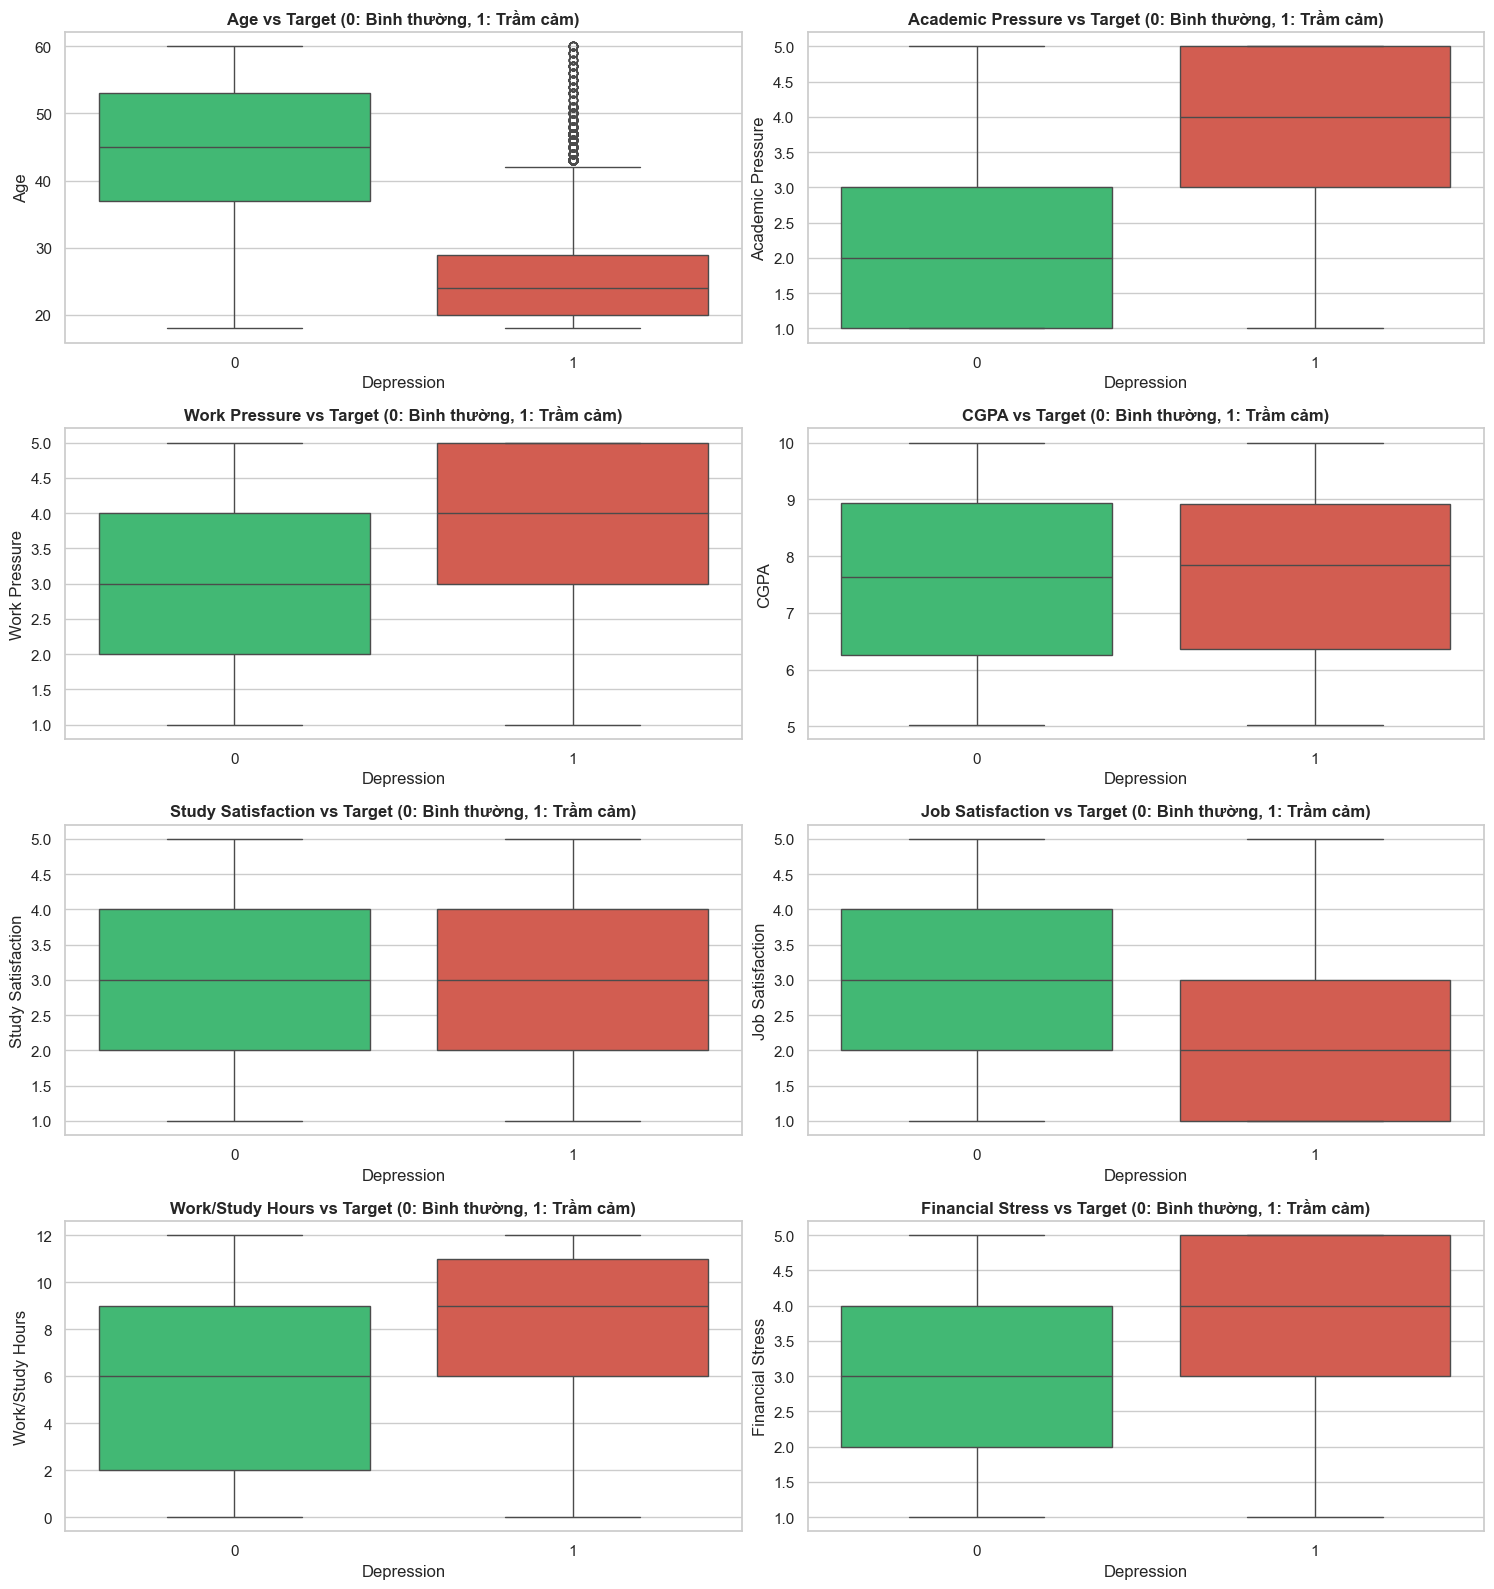

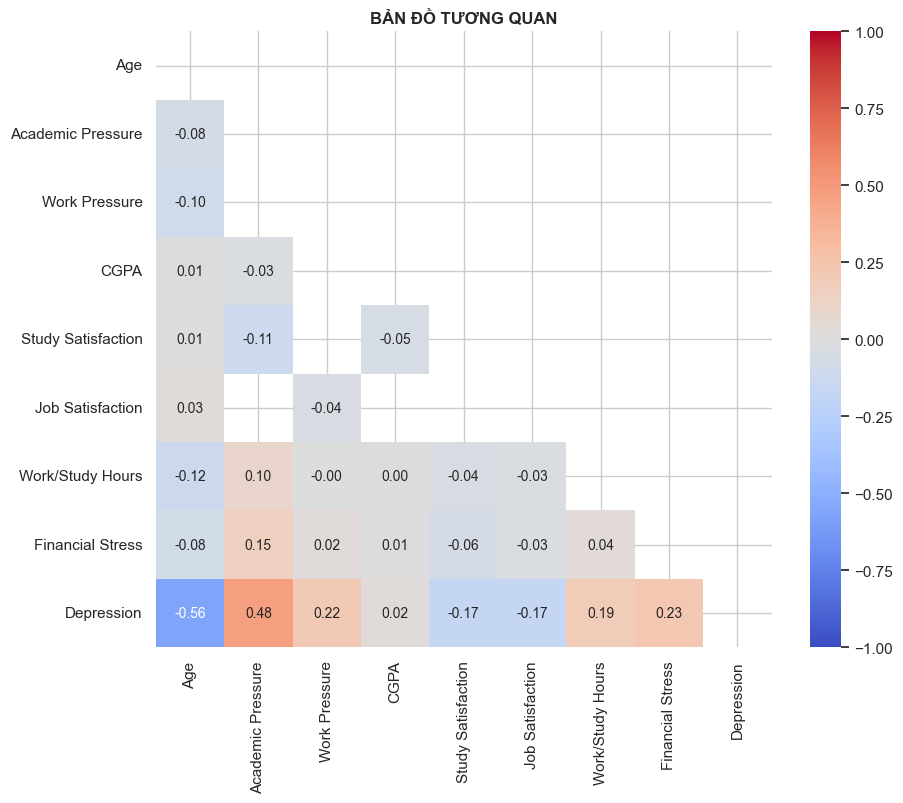


--- TOP CÁC BIẾN SỐ TƯƠNG QUAN MẠNH NHẤT VỚI TRẦM CẢM ---
Academic Pressure     0.475106
Financial Stress      0.227237
Work Pressure         0.216608
Work/Study Hours      0.191746
CGPA                  0.021829
Study Satisfaction   -0.168119
Job Satisfaction     -0.168524
Age                  -0.564671


In [21]:
print("="*50)
print("PHÂN TÍCH BIẾN SỐ & TƯƠNG QUAN ")
print("="*50)


eda_df = train_df.copy()

student_cols_eda = ['Academic Pressure', 'Study Satisfaction', 'CGPA']
worker_cols_eda = ['Work Pressure', 'Job Satisfaction']

for col in student_cols_eda:
    if col in eda_df.columns:
        eda_df.loc[eda_df['Working Professional or Student'] == 'Working Professional', col] = np.nan
        eda_df[col] = eda_df[col].replace(0, np.nan)
for col in worker_cols_eda:
    if col in eda_df.columns:
        eda_df.loc[eda_df['Working Professional or Student'] == 'Student', col] = np.nan
        eda_df[col] = eda_df[col].replace(0, np.nan)

n_cols_plot = 2
n_rows_num = int(np.ceil(len(num_cols) / n_cols_plot))
fig, axes = plt.subplots(n_rows_num, n_cols_plot, figsize=(15, 4 * n_rows_num))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=eda_df, x='Depression', y=col, ax=axes[i], hue='Depression', palette=["#2ecc71", "#e74c3c"], legend=False)
    axes[i].set_title(f'{col} vs Target (0: Bình thường, 1: Trầm cảm)', fontweight='bold')

for j in range(len(num_cols), len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# Vẽ Heatmap Correlation
plt.figure(figsize=(10, 8))
corr_matrix = eda_df[num_cols + ['Depression']].astype(float).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title('BẢN ĐỒ TƯƠNG QUAN', fontweight='bold')
plt.show()

print("\n--- TOP CÁC BIẾN SỐ TƯƠNG QUAN MẠNH NHẤT VỚI TRẦM CẢM ---")
top_corr = corr_matrix['Depression'].drop('Depression').sort_values(ascending=False)
print(top_corr.to_string())

Nhận xét:

Từ biểu đồ phân tích, ta thấy được: `Age`, `Academic Pressure` là 2 đặc trưng có miền giá trị không chồng lấn (phân loại mạnh) - Điều này hoàn toàn hợp lý với nhận xét về mắc trầm cảm có xu hướng trẻ, và thường là liên quan đến học sinh.

Các thuộc tính tương quan tuyến tính mạnh đến biến mục tiêu có thể kể đến là: `Academic Pressure`, `Financial Stress`, `Work Pressure`, `Age` (có các trị tuyệt đối hệ số tương quan trên 0.2) nhưng không có đặc trưng nào tương quan quá mạnh (> 0.9).